In [76]:
import pandas as pd
import matplotlib.pyplot as plt


In [77]:
df = pd.DataFrame({"Person":["A","B","C","D","E",'F','G','H','I',"J"],
                     "Looks":[9,5,8,4,7,3,8,6,7,8],
                     "Dancing":[8,2,9,3,5,1,7,4,6,5],
                     "Humor":[7,3,8,2,9,2,8,5,9,9],
                     "Talkative":[6,4,7,3,9,2,8,8,9,7],
                     "Confidence":[8,3,6,2,8,2,7,6,8,8]},
                    )

In [78]:
df

,Person,Looks,Dancing,Humor,Talkative,Confidence
0,A,9,8,7,6,8
1,B,5,2,3,4,3
2,C,8,9,8,7,6
3,D,4,3,2,3,2
4,E,7,5,9,9,8
5,F,3,1,2,2,2
6,G,8,7,8,8,7
7,H,6,4,5,8,6
8,I,7,6,9,9,8
9,J,8,5,9,7,8


In [79]:
df=df.drop(['Person'], axis=1)

In [80]:
print(df.shape)
print(df.info())     
print(df.dtypes)

(10, 5)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Looks       10 non-null     int64
 1   Dancing     10 non-null     int64
 2   Humor       10 non-null     int64
 3   Talkative   10 non-null     int64
 4   Confidence  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
None
Looks         int64
Dancing       int64
Humor         int64
Talkative     int64
Confidence    int64
dtype: object


In [81]:
df.isnull().sum()

Looks         0
Dancing       0
Humor         0
Talkative     0
Confidence    0
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.describe()

,Looks,Dancing,Humor,Talkative,Confidence
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,6.50000,5.000000,6.200000,6.300000,5.800000
std,1.95789,2.581989,2.936362,2.496664,2.529822
min,3.00000,1.000000,2.000000,2.000000,2.000000
25%,5.25000,3.250000,3.500000,4.500000,3.750000
50%,7.00000,5.000000,7.500000,7.000000,6.500000
75%,8.00000,6.750000,8.750000,8.000000,8.000000
max,9.00000,9.000000,9.000000,9.000000,8.000000


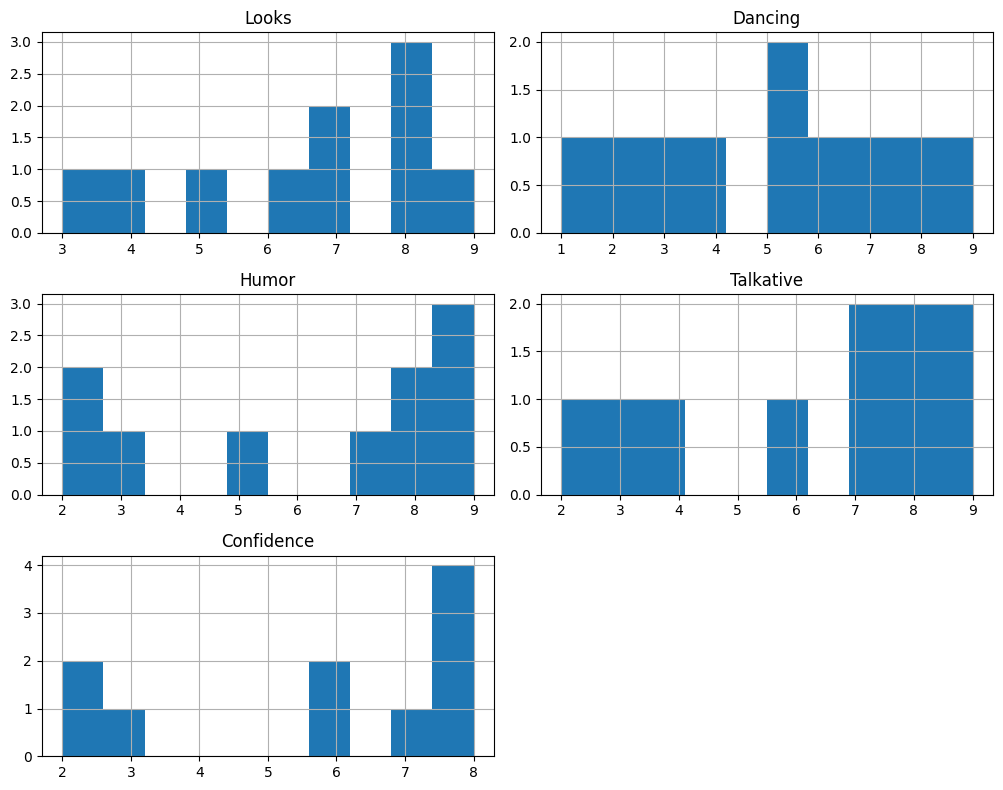

In [84]:
# histogram
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()


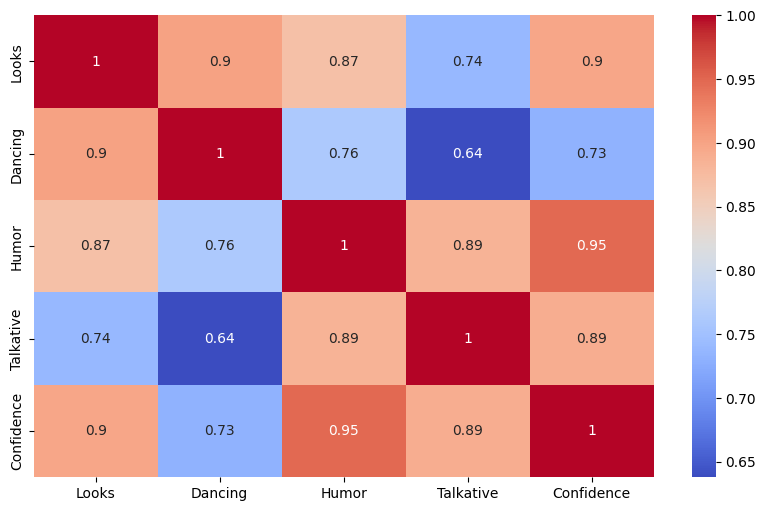

In [85]:
# correlation matrix
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

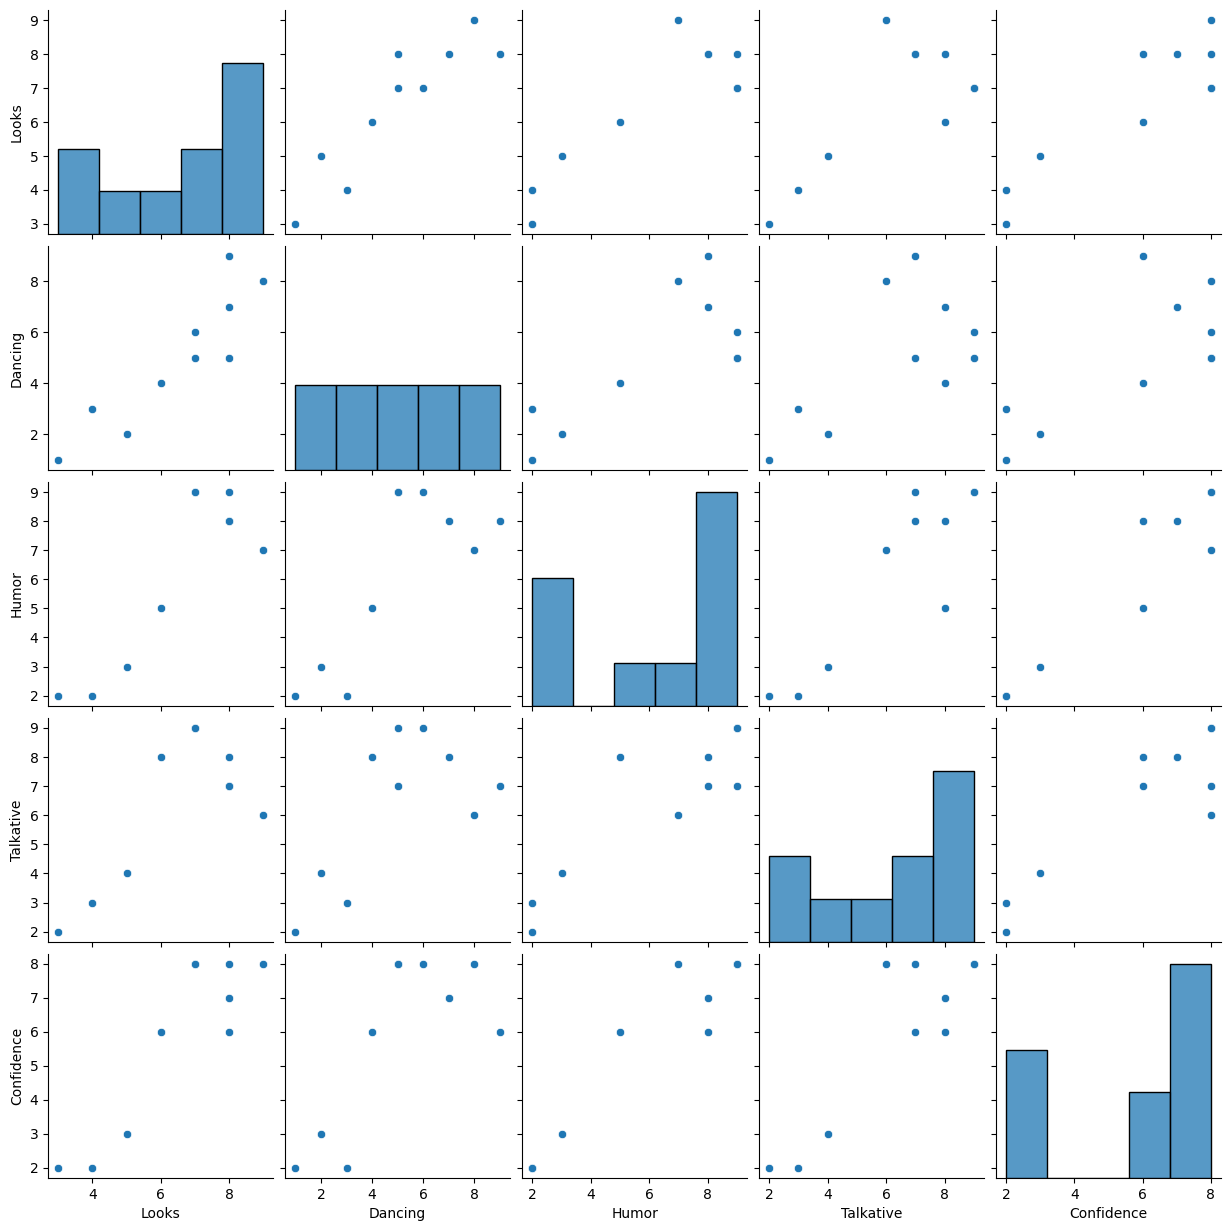

In [86]:
sns.pairplot(df)
plt.show()

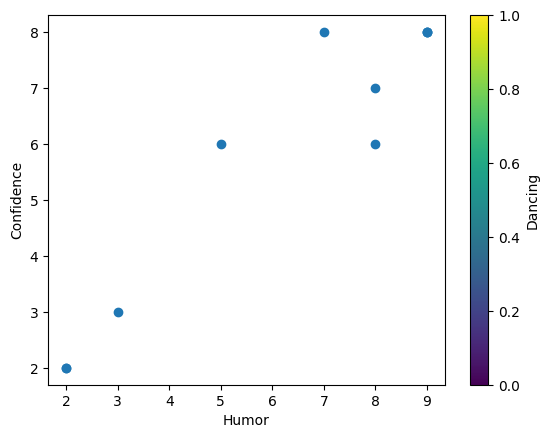

In [87]:
# scatter plot
plt.scatter(df['Humor'], df['Confidence'])
plt.xlabel('Humor')
plt.ylabel("Confidence")
plt.colorbar(label='Dancing')
plt.show()

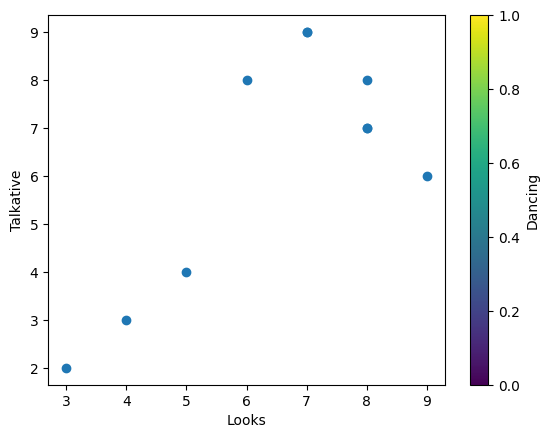

In [88]:
# scatter plot
plt.scatter(df['Looks'], df['Talkative'])
plt.xlabel('Looks')
plt.ylabel("Talkative")
plt.colorbar(label='Dancing')
plt.show()

In [89]:
# # three categories of data social score      personlatiy        enternor
# high con,good humor,    introvert,extrovert       funny,boring

In [90]:
# making the labels for the data
df['Social_Score'] = (df['Confidence'] + df['Humor']) / 2

def social_label(score):
    if score >= 8:
        return 'Highly'
    elif score >= 6:
        return 'Moderately'
    else:
        return 'Less'

df['Social_Label'] = df['Social_Score'].apply(social_label)


In [91]:
def personality(score):
    if score >= 6:
        return 'Extrovert'
    else:
        return 'Introvert'

df['Personality'] = df['Talkative'].apply(personality)

In [92]:
df['Entertainer_Score'] = (df['Dancing'] + df['Talkative']) / 2

def entertainer(score):
    if score >= 6:
        return 'Funny'
    else:
        return 'Boring'
        
df['Entertainer_Score'] = df['Entertainer_Score'].apply(entertainer)

In [93]:
df

,Looks,Dancing,Humor,Talkative,Confidence,Social_Score,Social_Label,Personality,Entertainer_Score
0,9,8,7,6,8,7.5,Moderately,Extrovert,Funny
1,5,2,3,4,3,3.0,Less,Introvert,Boring
2,8,9,8,7,6,7.0,Moderately,Extrovert,Funny
3,4,3,2,3,2,2.0,Less,Introvert,Boring
4,7,5,9,9,8,8.5,Highly,Extrovert,Funny
5,3,1,2,2,2,2.0,Less,Introvert,Boring
6,8,7,8,8,7,7.5,Moderately,Extrovert,Funny
7,6,4,5,8,6,5.5,Less,Extrovert,Funny
8,7,6,9,9,8,8.5,Highly,Extrovert,Funny
9,8,5,9,7,8,8.5,Highly,Extrovert,Funny


In [ ]:
# K-Means Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df.drop(['Social_Score', 'Social_Label', 'Personality', 'Entertainer_Score'], axis=1))
print(df['Cluster'].value_counts())

Cluster
1    5
0    3
2    2
Name: count, dtype: int64


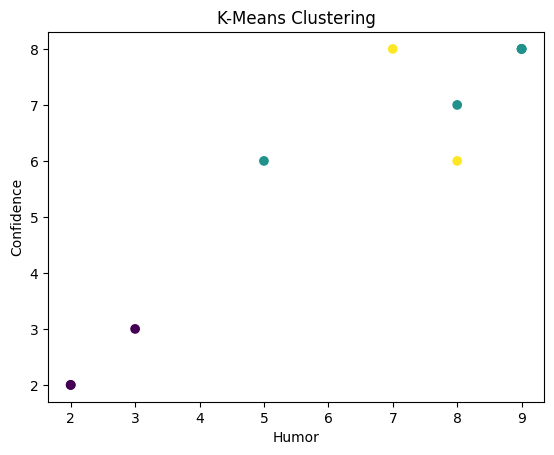

In [96]:
# plotting the clusters
plt.scatter(df['Humor'], df['Confidence'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Humor')
plt.ylabel('Confidence')
plt.title('K-Means Clustering')
plt.show()